# Compare YOLO26 Models

Notebook ini membandingkan `yolo26_interval2` dan `yolo26_lele-2` pada:
- `mAP50`
- `mAP50-95`
- latency inferensi rata-rata per image

In [1]:
from pathlib import Path
from ultralytics import YOLO
import torch
import pandas as pd
import time
import matplotlib.pyplot as plt

DATA_YAML = 'data.yaml'
IMG_SIZE = 640
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
TEST_DIR = Path('dataset_split/test/images')
N_SAMPLES = 50

MODELS = {
    'yolo26_interval2': 'runs/detect/runs/train/yolo26_interval2/weights/best.pt',
    'yolo26_lele-2': 'runs/detect/runs/train/yolo26_lele-2/weights/best.pt',
}

In [2]:
def load_model(path):
    return YOLO(str(path))

def read_peak_metrics(results_path):
    df = pd.read_csv(results_path)
    return {
        'mAP50': float(df['metrics/mAP50(B)'].max()),
        'mAP50-95': float(df['metrics/mAP50-95(B)'].max()),
    }

def evaluate_model(name, model_path):
    model_path = Path(model_path)
    if not model_path.exists():
        return {
            'model': name,
            'path': str(model_path),
            'status': 'missing'
        }

    results_path = model_path.parent.parent / 'results.csv'
    if not results_path.exists():
        return {
            'model': name,
            'path': str(model_path),
            'status': 'missing_results'
        }

    model = load_model(model_path)
    metrics = read_peak_metrics(results_path)

    imgs = sorted([p for p in TEST_DIR.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}])[:N_SAMPLES]
    if not imgs:
        return {
            'model': name,
            'path': str(model_path),
            'status': 'no_test_images'
        }

    _ = model.predict(source=str(imgs[0]), imgsz=IMG_SIZE, device=DEVICE, verbose=False)

    start = time.perf_counter()
    for image_path in imgs:
        _ = model.predict(source=str(image_path), imgsz=IMG_SIZE, device=DEVICE, verbose=False)
    total = time.perf_counter() - start
    latency_ms = (total / len(imgs)) * 1000

    return {
        'model': name,
        'path': str(model_path),
        'status': 'ok',
        'mAP50': metrics['mAP50'],
        'mAP50-95': metrics['mAP50-95'],
        'latency_ms_per_image': latency_ms,
        'sample_count': len(imgs),
    }

results = []
for name, path in MODELS.items():
    results.append(evaluate_model(name, path))

df = pd.DataFrame(results)
df

,model,path,status,mAP50,mAP50-95,latency_ms_per_image,sample_count
0,yolo26_interval2,runs\detect\runs\train\yolo26_interval2\weight...,ok,0.95911,0.79586,9.762012,50
1,yolo26_lele-2,runs\detect\runs\train\yolo26_lele-2\weights\b...,ok,0.99500,0.87244,9.904982,50


In [ ]:
df.to_csv('compare_results_yolo26.csv', index=False)
print('Saved: compare_results_yolo26.csv')

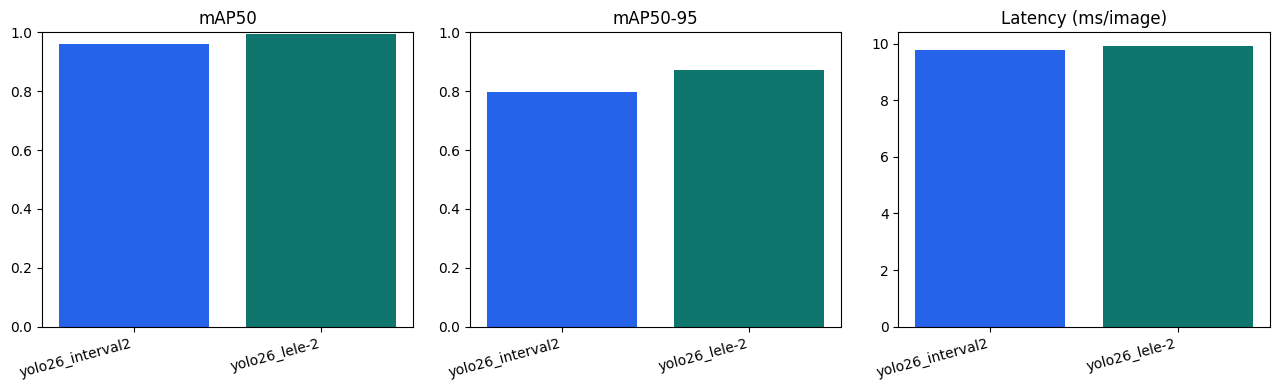

              model    mAP50  mAP50-95  latency_ms_per_image  sample_count  \
0  yolo26_interval2  0.95911   0.79586              9.762012            50   
1     yolo26_lele-2  0.99500   0.87244              9.904982            50   

  status  
0     ok  
1     ok  


In [3]:
plot_df = df[df['status'] == 'ok'].copy()
if plot_df.empty:
    print('No valid results to plot.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    colors = ['#2563eb', '#0f766e']

    axes[0].bar(plot_df['model'], plot_df['mAP50'], color=colors)
    axes[0].set_title('mAP50')
    axes[0].set_ylim(0, 1)

    axes[1].bar(plot_df['model'], plot_df['mAP50-95'], color=colors)
    axes[1].set_title('mAP50-95')
    axes[1].set_ylim(0, 1)

    axes[2].bar(plot_df['model'], plot_df['latency_ms_per_image'], color=colors)
    axes[2].set_title('Latency (ms/image)')

    for ax in axes:
        ax.tick_params(axis='x', rotation=15)
        for label in ax.get_xticklabels():
            label.set_ha('right')

    plt.tight_layout()
    plt.show()

print(df[['model', 'mAP50', 'mAP50-95', 'latency_ms_per_image', 'sample_count', 'status']])